# Pursuit Problem Simulation

## Problem Statement

A fighter plane is chasing a bomber plane using the Pure Pursuit Algorithm.

The fighter always moves directly toward the current position of the bomber. At every time step, the distance between the fighter and bomber is calculated. If the distance becomes less than or equal to the missile firing range, the fighter fires a missile and the simulation stops.

## Given Data

Initial position of fighter plane:

Fighter position = (0, 60)

Fighter speed:

s = 25 km/min

Missile firing range:

R = 12 km

Maximum pursuit time:

15 minutes

The bomber plane position at different times is given below:

| Time, t (min) | Bomber x-position, xb | Bomber y-position, yb |
|---|---:|---:|
| 0 | 100 | 0 |
| 1 | 110 | 3 |
| 2 | 120 | 6 |
| 3 | 130 | 10 |
| 4 | 140 | 15 |
| 5 | 149 | 20 |
| 6 | 158 | 26 |
| 7 | 163 | 32 |

## Formula

Distance between fighter and bomber:

D = sqrt((xb - xf)^2 + (yb - yf)^2)

Direction components:

cosθ = (xb - xf) / D

sinθ = (yb - yf) / D

Fighter new position:

xf(new) = xf(old) + s × cosθ

yf(new) = yf(old) + s × sinθ

## Required Task

Using the Pure Pursuit Algorithm:

1. Calculate the distance between the fighter and bomber at each time step.
2. Calculate the new position of the fighter plane.
3. Continue the simulation until the bomber comes within missile firing range.
4. Print the result table.
5. Draw a graph showing the path of the bomber and fighter.

   Time  Bomber X  Bomber Y  Fighter X  Fighter Y  Distance New Fighter X  \
0     0       100         0       0.00      60.00    116.62         21.44   
1     1       110         3      21.44      47.14     98.95         43.81   
2     2       120         6      43.81      35.99     81.88         67.08   
3     3       130        10      67.08      26.83     65.14         91.23   
4     4       140        15      91.23      20.37     49.07        116.08   
5     5       149        20     116.08      17.63     33.01        141.01   
6     6       158        26     141.01      19.43     18.22        164.33   
7     7       163        32     164.33      28.45      3.79             -   

  New Fighter Y        Result  
0         47.14      Continue  
1         35.99      Continue  
2         26.83      Continue  
3         20.37      Continue  
4         17.63      Continue  
5         19.43      Continue  
6         28.45      Continue  
7             -  Fire Missile  


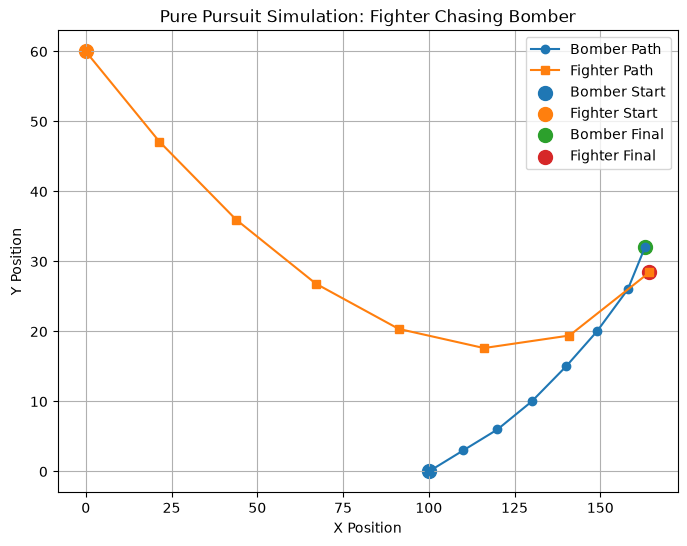

In [8]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Given Data
# -----------------------------

# Fighter initial position
xf = 0.0
yf = 60.0

# Fighter speed
s = 25.0   # km/min

# Missile firing range
missile_range = 12.0   # km

# Bomber position data: time, xb, yb
bomber_data = [
    [0, 100, 0],
    [1, 110, 3],
    [2, 120, 6],
    [3, 130, 10],
    [4, 140, 15],
    [5, 149, 20],
    [6, 158, 26],
    [7, 163, 32]
]

# Store simulation results
results = []

# Store path for graph
fighter_x_path = []
fighter_y_path = []
bomber_x_path = []
bomber_y_path = []

# -----------------------------
# Pure Pursuit Algorithm
# -----------------------------

for data in bomber_data:
    t = data[0]
    xb = data[1]
    yb = data[2]

    # Calculate distance
    distance = math.sqrt((xb - xf)**2 + (yb - yf)**2)

    # Store paths for graph
    fighter_x_path.append(xf)
    fighter_y_path.append(yf)
    bomber_x_path.append(xb)
    bomber_y_path.append(yb)

    # Check missile firing condition
    if distance <= missile_range:
        results.append([
            t,
            round(xb, 2),
            round(yb, 2),
            round(xf, 2),
            round(yf, 2),
            round(distance, 2),
            "-",
            "-",
            "Fire Missile"
        ])
        break

    # Calculate cos(theta) and sin(theta)
    cos_theta = (xb - xf) / distance
    sin_theta = (yb - yf) / distance

    # Calculate fighter new position
    xf_new = xf + s * cos_theta
    yf_new = yf + s * sin_theta

    # Store result
    results.append([
        t,
        round(xb, 2),
        round(yb, 2),
        round(xf, 2),
        round(yf, 2),
        round(distance, 2),
        round(xf_new, 2),
        round(yf_new, 2),
        "Continue"
    ])

    # Update fighter position
    xf = xf_new
    yf = yf_new

# -----------------------------
# Display Result Table
# -----------------------------

df = pd.DataFrame(
    results,
    columns=[
        "Time",
        "Bomber X",
        "Bomber Y",
        "Fighter X",
        "Fighter Y",
        "Distance",
        "New Fighter X",
        "New Fighter Y",
        "Result"
    ]
)

print(df)

# -----------------------------
# Plot Graph
# -----------------------------

plt.figure(figsize=(8, 6))

# Bomber path
plt.plot(
    bomber_x_path,
    bomber_y_path,
    marker="o",
    label="Bomber Path"
)

# Fighter path
plt.plot(
    fighter_x_path,
    fighter_y_path,
    marker="s",
    label="Fighter Path"
)

# Mark starting points
plt.scatter(bomber_x_path[0], bomber_y_path[0], s=100, label="Bomber Start")
plt.scatter(fighter_x_path[0], fighter_y_path[0], s=100, label="Fighter Start")

# Mark final points
plt.scatter(bomber_x_path[-1], bomber_y_path[-1], s=100, label="Bomber Final")
plt.scatter(fighter_x_path[-1], fighter_y_path[-1], s=100, label="Fighter Final")

plt.title("Pure Pursuit Simulation: Fighter Chasing Bomber")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)

plt.show()

# Chemical Reaction Simulation Problem

A reversible chemical reaction is given:

H₂ + O₂ ⇌ H₂O

Let,

- C₁ = concentration of H₂
- C₂ = concentration of O₂
- C₃ = concentration of H₂O

Given:

| Parameter | Value |
|---|---|
| C₁(0) | 50 |
| C₂(0) | 25 |
| C₃(0) | 0 |
| k₁ | 0.025 |
| k₂ | 0.01 |
| Δt | 0.2 min |
| Total time | 3 min |

The differential equations are:

dC₁/dt = k₂C₃ − k₁C₁C₂

dC₂/dt = k₂C₃ − k₁C₁C₂

dC₃/dt = 2k₁C₁C₂ − 2k₂C₃

Use Euler’s Method:

C_new = C_old + (dC/dt) × Δt

Simulate the reaction from t = 0 min to t = 3 min.

Find the values of C₁, C₂, and C₃ at each time step.

Also draw a graph of C₁, C₂, and C₃ with respect to time.

    Time (min)  H2 (C1)  O2 (C2)  H2O (C3)
0          0.0   50.000   25.000     0.000
1          0.2   43.750   18.750    12.500
2          0.4   39.673   14.673    20.653
3          0.6   36.804   11.804    26.392
4          0.8   34.685    9.685    30.631
5          1.0   33.066    8.066    33.867
6          1.2   31.800    6.800    36.399
7          1.4   30.792    5.792    38.416
8          1.6   29.977    4.977    40.046
9          1.8   29.311    4.311    41.378
10         2.0   28.762    3.762    42.476
11         2.2   28.306    3.306    43.388
12         2.4   27.925    2.925    44.150
13         2.6   27.605    2.605    44.790
14         2.8   27.335    2.335    45.330
15         3.0   27.106    2.106    45.787


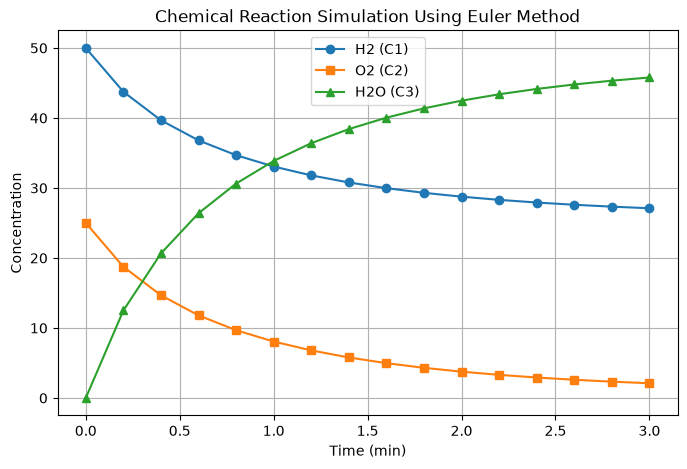

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Reaction constants
k1 = 0.025
k2 = 0.01

# Initial concentrations
c1 = 50.0     # H2
c2 = 25.0     # O2
c3 = 0.0      # H2O

# Time settings
dt = 0.2
total_time = 3.0

# Store results
results = []

# Initial time
t = 0.0
results.append([t, c1, c2, c3])

# Number of iterations
steps = int(total_time / dt)

# Euler Method
for i in range(steps):
    # Differential equations
    dc1_dt = k2 * c3 - k1 * c1 * c2
    dc2_dt = k2 * c3 - k1 * c1 * c2
    dc3_dt = 2 * k1 * c1 * c2 - 2 * k2 * c3

    # Euler update formula
    c1 = c1 + dc1_dt * dt
    c2 = c2 + dc2_dt * dt
    c3 = c3 + dc3_dt * dt

    # Update time
    t = t + dt

    # Store updated values
    results.append([round(t, 1), c1, c2, c3])

# Create DataFrame
df = pd.DataFrame(
    results,
    columns=["Time (min)", "H2 (C1)", "O2 (C2)", "H2O (C3)"]
)

# Print result table
print(df.round(3))

# -----------------------------
# Graph Plot
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(df["Time (min)"], df["H2 (C1)"], marker="o", label="H2 (C1)")
plt.plot(df["Time (min)"], df["O2 (C2)"], marker="s", label="O2 (C2)")
plt.plot(df["Time (min)"], df["H2O (C3)"], marker="^", label="H2O (C3)")

plt.title("Chemical Reaction Simulation Using Euler Method")
plt.xlabel("Time (min)")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)

plt.show()

# Chasing Problem

Four objects A, B, C, and D are moving in a 2D plane.

Initial positions and speeds are:

| Object | Initial Position | Speed |
|---|---|---|
| A | (0, 0) | 30 km/hr |
| B | (0, 10) | 25 km/hr |
| C | (0, 20) | 20 km/hr |
| D | (0, 30) | 15 km/hr |

Chasing rule:

- A chases B
- B chases C
- C chases D
- D chases fixed target T(30, 50)

Given:

- Time step, Δt = 0.2 hr
- Hit condition: distance < 0.005 km

Use the formula:

x_new = x_old + V × ((x_target - x_old) / distance) × Δt

y_new = y_old + V × ((y_target - y_old) / distance) × Δt

where,

distance = √((x_target - x_old)² + (y_target - y_old)²)

Simulate the chasing process until all objects reach their targets.

Also draw the movement paths of A, B, C, and D.

    Time     A_x     A_y     B_x     B_y     C_x     C_y     D_x     D_y  \
0    0.0   0.000   0.000   0.000  10.000   0.000  20.000   0.000  30.000   
1    0.2   0.000   6.000   0.000  15.000   0.000  24.000   2.496  31.664   
2    0.4   0.000  12.000   0.000  20.000   1.239  27.803   4.992  33.328   
3    0.6   0.000  18.000   0.784  24.938   3.487  31.112   7.488  34.992   
4    0.8   0.674  23.962   2.789  29.519   6.358  33.896   9.985  36.656   
5    1.0   2.789  29.519   5.948  33.394   9.541  36.319  12.481  38.321   
6    1.2   5.948  33.394   9.541  36.319  12.481  38.321  14.977  39.985   
7    1.4   9.541  36.319  12.481  38.321  14.977  39.985  17.473  41.649   
8    1.6  12.481  38.321  14.977  39.985  17.473  41.649  19.969  43.313   
9    1.8  14.977  39.985  17.473  41.649  19.969  43.313  22.465  44.977   
10   2.0  17.473  41.649  19.969  43.313  22.465  44.977  24.962  46.641   
11   2.2  19.969  43.313  22.465  44.977  24.962  46.641  27.458  48.305   
12   2.4  22

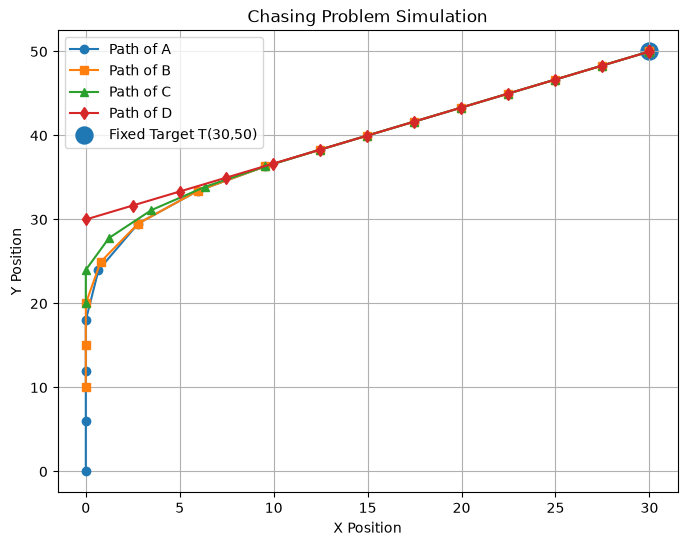

In [7]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------
# Given data
# --------------------------------

dt = 0.2                  # time step in hour
hit_condition = 0.005     # km

# Fixed target point for D
target_T = [30.0, 50.0]

# Initial positions
A = [0.0, 0.0]
B = [0.0, 10.0]
C = [0.0, 20.0]
D = [0.0, 30.0]

# Speeds in km/hr
speed_A = 30.0
speed_B = 25.0
speed_C = 20.0
speed_D = 15.0

# --------------------------------
# Function to calculate distance
# --------------------------------

def distance(p1, p2):
    return math.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)


# --------------------------------
# Function to update position
# --------------------------------

def update_position(current, target, speed, dt):
    d = distance(current, target)

    # If object is already very close to target
    if d <= hit_condition:
        return target.copy()

    # Distance covered in one time step
    movement = speed * dt

    # To avoid crossing/overshooting the target
    if d <= movement:
        return target.copy()

    x_new = current[0] + speed * ((target[0] - current[0]) / d) * dt
    y_new = current[1] + speed * ((target[1] - current[1]) / d) * dt

    return [x_new, y_new]


# --------------------------------
# Simulation
# --------------------------------

time = 0.0
results = []

# For graph
path_A_x = []
path_A_y = []
path_B_x = []
path_B_y = []
path_C_x = []
path_C_y = []
path_D_x = []
path_D_y = []

while True:
    # Calculate current distances
    AB = distance(A, B)
    BC = distance(B, C)
    CD = distance(C, D)
    DT = distance(D, target_T)

    # Store result
    results.append([
        round(time, 2),
        round(A[0], 3), round(A[1], 3),
        round(B[0], 3), round(B[1], 3),
        round(C[0], 3), round(C[1], 3),
        round(D[0], 3), round(D[1], 3),
        round(AB, 3),
        round(BC, 3),
        round(CD, 3),
        round(DT, 3)
    ])

    # Store path for graph
    path_A_x.append(A[0])
    path_A_y.append(A[1])

    path_B_x.append(B[0])
    path_B_y.append(B[1])

    path_C_x.append(C[0])
    path_C_y.append(C[1])

    path_D_x.append(D[0])
    path_D_y.append(D[1])

    # Stop condition
    if AB <= hit_condition and BC <= hit_condition and CD <= hit_condition and DT <= hit_condition:
        break

    # Store old positions for simultaneous update
    old_A = A.copy()
    old_B = B.copy()
    old_C = C.copy()
    old_D = D.copy()

    # Update positions
    A = update_position(old_A, old_B, speed_A, dt)
    B = update_position(old_B, old_C, speed_B, dt)
    C = update_position(old_C, old_D, speed_C, dt)
    D = update_position(old_D, target_T, speed_D, dt)

    # Update time
    time = time + dt

# --------------------------------
# Result table
# --------------------------------

df = pd.DataFrame(
    results,
    columns=[
        "Time",
        "A_x", "A_y",
        "B_x", "B_y",
        "C_x", "C_y",
        "D_x", "D_y",
        "AB Distance",
        "BC Distance",
        "CD Distance",
        "DT Distance"
    ]
)

print(df)

# --------------------------------
# Final result
# --------------------------------

print("\nFinal Time:", round(time, 2), "hr")
print("Final Position of A:", A)
print("Final Position of B:", B)
print("Final Position of C:", C)
print("Final Position of D:", D)
print("Fixed Target:", target_T)
print("Result: All objects reached their targets.")

# --------------------------------
# Graph
# --------------------------------

plt.figure(figsize=(8, 6))

plt.plot(path_A_x, path_A_y, marker="o", label="Path of A")
plt.plot(path_B_x, path_B_y, marker="s", label="Path of B")
plt.plot(path_C_x, path_C_y, marker="^", label="Path of C")
plt.plot(path_D_x, path_D_y, marker="d", label="Path of D")

plt.scatter(target_T[0], target_T[1], s=150, label="Fixed Target T(30,50)")

plt.title("Chasing Problem Simulation")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)

plt.show()